In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.0 MB/s eta 0:00:00


In [ ]:
"""
#VERI SERI INDIRME

import os
import torch
from torch_geometric.datasets import AirfRANS

# Drive'ının içinde bu proje için kalıcı bir klasör oluşturuyoruz
base_dir = '/content/drive/MyDrive/AeroML_Project'
os.makedirs(base_dir, exist_ok=True)

# Veri setinin ineceği YENİ ve KALICI adres
dataset_path = os.path.join(base_dir, 'AirfRANS_Dataset')

print(f"Veriler kalıcı olarak şuraya indirilecek: {dataset_path}")
print("AirfRANS veri seti indiriliyor... (Bu son indirişimiz olacak)")

# task='full' parametresini unutmuyoruz
train_dataset = AirfRANS(root=dataset_path, task='full', train=True)
test_dataset = AirfRANS(root=dataset_path, task='full', train=False)

print("İşlem Tamam! Artık sekmeyi kapatsan bile verilerin Drive'ında güvende.")

"""

'\n#VERI SERI INDIRME\n\nimport os\nimport torch\nfrom torch_geometric.datasets import AirfRANS\n\n# Drive\'ının içinde bu proje için kalıcı bir klasör oluşturuyoruz\nbase_dir = \'/content/drive/MyDrive/AeroML_Project\'\nos.makedirs(base_dir, exist_ok=True)\n\n# Veri setinin ineceği YENİ ve KALICI adres\ndataset_path = os.path.join(base_dir, \'AirfRANS_Dataset\')\n\nprint(f"Veriler kalıcı olarak şuraya indirilecek: {dataset_path}")\nprint("AirfRANS veri seti indiriliyor... (Bu son indirişimiz olacak)")\n\n# task=\'full\' parametresini unutmuyoruz\ntrain_dataset = AirfRANS(root=dataset_path, task=\'full\', train=True)\ntest_dataset = AirfRANS(root=dataset_path, task=\'full\', train=False)\n\nprint("İşlem Tamam! Artık sekmeyi kapatsan bile verilerin Drive\'ında güvende.")\n\n'

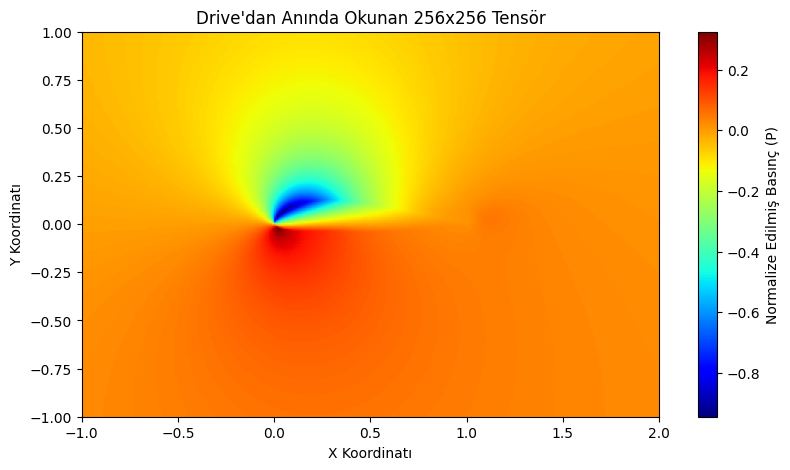

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1. Drive'a kaydettiğimiz ilk tensör dosyasının yolu
file_path = '/content/drive/MyDrive/AeroML_Project/tensordata/train/sample_0.pt'

# 2. Dosyayı RAM'e yükle (Milisaniyeler sürer, CPU'yu hiç yormaz!)
loaded_data = torch.load(file_path)

# 3. Veriyi Parçalayalım
# target tensörümüzün boyutu [3, 256, 256] idi.
# Sıralamamız: 0->Basınç, 1->Ux, 2->Uy
pressure_tensor = loaded_data['target'][0]

# PyTorch tensörünü Matplotlib'in anlayacağı Numpy dizisine çeviriyoruz
grid_p = pressure_tensor.numpy()

# 4. Kaydederken kullandığımız sabit sınırları tanımlıyoruz
x_min, x_max = -1.0, 2.0
y_min, y_max = -1.0, 1.0

# 5. Görselleştirme
plt.figure(figsize=(10, 5))
plt.imshow(grid_p.T, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='jet')
plt.colorbar(label='Normalize Edilmiş Basınç (P)')
plt.title("Drive'dan Anında Okunan 256x256 Tensör")
plt.xlabel("X Koordinatı")
plt.ylabel("Y Koordinatı")
plt.show()

In [ ]:
import os
import torch
import numpy as np
from scipy.interpolate import griddata
from tqdm.auto import tqdm
from torch_geometric.datasets import AirfRANS # Kütüphaneyi tekrar çağırıyoruz

# 1. Klasör yolları
base_dir = '/content/drive/MyDrive/AeroML_Project'
dataset_path = os.path.join(base_dir, 'AirfRANS_Dataset')

# 2. Değişkenleri tekrar tanımlıyoruz (Drive'da zaten olduğu için anında geçer)
print("Veri seti Drive'dan okunuyor...")
train_dataset = AirfRANS(root=dataset_path, task='full', train=True)
test_dataset = AirfRANS(root=dataset_path, task='full', train=False)

# 3. İşleme Fonksiyonu
def process_and_save_dataset(dataset, folder_name):
    save_dir = os.path.join(base_dir, 'tensordata', folder_name)
    os.makedirs(save_dir, exist_ok=True)

    num_samples = len(dataset)
    print(f"\n{folder_name.upper()} klasörü için {num_samples} simülasyon işleniyor...")

    x_min, x_max = -1.0, 2.0
    y_min, y_max = -1.0, 1.0

    for i in tqdm(range(num_samples)):
        file_path = os.path.join(save_dir, f"sample_{i}.pt")
        # Dosya varsa atla (kaldığı yerden devam etmesi için)
        if os.path.exists(file_path):
            continue

        data = dataset[i]
        points = data.pos.numpy()

        ux = data.y[:, 0].numpy()
        uy = data.y[:, 1].numpy()
        p = data.y[:, 2].numpy()
        sdf = data.x[:, 2].numpy()

        grid_x, grid_y = np.mgrid[x_min:x_max:256j, y_min:y_max:256j]

        grid_sdf = griddata(points, sdf, (grid_x, grid_y), method='linear', fill_value=0)
        grid_p = griddata(points, p, (grid_x, grid_y), method='linear', fill_value=0)
        grid_ux = griddata(points, ux, (grid_x, grid_y), method='linear', fill_value=0)
        grid_uy = griddata(points, uy, (grid_x, grid_y), method='linear', fill_value=0)

        grid_p = np.clip(grid_p, -2000, 1000) / 2000.0
        grid_ux = grid_ux / 100.0
        grid_uy = grid_uy / 100.0

        grid_sdf = np.nan_to_num(grid_sdf, nan=0.0)
        grid_p = np.nan_to_num(grid_p, nan=0.0)
        grid_ux = np.nan_to_num(grid_ux, nan=0.0)
        grid_uy = np.nan_to_num(grid_uy, nan=0.0)

        inputs = torch.tensor(grid_sdf, dtype=torch.float32).unsqueeze(0)
        targets = torch.stack([
            torch.tensor(grid_p, dtype=torch.float32),
            torch.tensor(grid_ux, dtype=torch.float32),
            torch.tensor(grid_uy, dtype=torch.float32)
        ])

        torch.save({'input': inputs, 'target': targets}, file_path)

# İşlemi Başlat
process_and_save_dataset(train_dataset, 'train')
process_and_save_dataset(test_dataset, 'test')

print("TÜM VERİLER BAŞARIYLA DRIVE'A KAYDEDİLDİ!")

Veri seti Drive'dan okunuyor...

TRAIN klasörü için 800 simülasyon işleniyor...


  0%|          | 0/800 [00:00<?, ?it/s]


TEST klasörü için 200 simülasyon işleniyor...


  0%|          | 0/200 [00:00<?, ?it/s]

TÜM VERİLER BAŞARIYLA DRIVE'A KAYDEDİLDİ!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Temel Yapı Taşı: Kalıntı Bloğu (Residual Block)
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Atlama Bağlantısı (Shortcut)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  # Girdiyi çıkışa doğrudan ekliyoruz
        out = F.relu(out)
        return out

# 2. Ana Model: ResUNet
class AeroResUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=3):
        super(AeroResUNet, self).__init__()

        # --- ENCODER (Daraltma / Çıkarım Katmanı) ---
        self.enc1 = ResBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ResBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # --- BOTTLENECK (Darboğaz) ---
        self.bottleneck = ResBlock(256, 512)

        # --- DECODER (Genişletme / Tahmin Katmanı) ---
        # Yukarı örnekleme (Upsampling) için Transposed Convolution kullanıyoruz
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ResBlock(512, 256) # 256 (Aşağıdan gelen) + 256 (Yataydan gelen) = 512

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ResBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ResBlock(128, 64)

        # --- ÇIKIŞ KATMANI ---
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder & Skip Connections (Yatay Bağlantılar)
        u3 = self.up3(b)
        c3 = torch.cat([u3, e3], dim=1) # Encoder'dan gelen veri ile birleştirme
        d3 = self.dec3(c3)

        u2 = self.up2(d3)
        c2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(c2)

        u1 = self.up1(d2)
        c1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(c1)

        # Final Çıktısı
        out = self.final_conv(d1)
        return out

# 3. Modeli Test Edelim (Doğru çalışıp çalışmadığını kontrol ediyoruz)
if __name__ == "__main__":
    # Dummy (Sahte) bir tensör üretiyoruz. Boyut: [Batch Size=1, Channels=1, Height=256, Width=256]
    dummy_input = torch.randn(1, 1, 256, 256)

    # Modeli başlat
    model = AeroResUNet(in_channels=1, out_channels=3)

    # Tensörü modele sok
    output = model(dummy_input)

    print(f"Girdi Boyutu: {dummy_input.shape}")
    print(f"Çıktı Boyutu: {output.shape}")

Girdi Boyutu: torch.Size([1, 1, 256, 256])
Çıktı Boyutu: torch.Size([1, 3, 256, 256])


In [ ]:
import torch
import os
from tqdm.auto import tqdm
from torch_geometric.datasets import AirfRANS

base_dir = '/content/drive/MyDrive/AeroML_Project'
dataset_path = os.path.join(base_dir, 'AirfRANS_Dataset')

print("Orijinal veri seti referans için RAM'e alınıyor...")
train_dataset = AirfRANS(root=dataset_path, task='full', train=True)
test_dataset = AirfRANS(root=dataset_path, task='full', train=False)

def inject_physics_to_tensors(dataset, folder_name):
    save_dir = os.path.join(base_dir, 'tensordata', folder_name)
    num_samples = len(dataset)

    for i in tqdm(range(num_samples), desc=f"{folder_name.upper()} Klasörüne Fizik Enjekte Ediliyor"):
        file_path = os.path.join(save_dir, f"sample_{i}.pt")
        if not os.path.exists(file_path):
            continue

        # 1. Kayıtlı dosyayı oku
        saved_data = torch.load(file_path)
        inputs = saved_data['input'] # Şu anki boyut: [1, 256, 256] (Sadece Geometri)

        # Eğer zaten 3 kanallı yaptıysak (kodu ikinci kez çalıştırırsan) atla
        if inputs.shape[0] == 3:
            continue

        # 2. AirfRANS verisinden Rüzgar Hızını (Freestream Velocity) çek
        # Veri setinde x[:, 0] X hızını, x[:, 1] Y hızını (Hücum açısını belirler) verir.
        # Hedef verileri 100'e böldüğümüz için bunları da 100'e bölerek normalize ediyoruz.
        ux_in = dataset[i].x[0, 0].item() / 100.0
        uy_in = dataset[i].x[0, 1].item() / 100.0

        # 3. Modelin her pikselde rüzgarı hissetmesi için 256x256'lık sabit matrisler oluştur
        ux_channel = torch.full((1, 256, 256), ux_in, dtype=torch.float32)
        uy_channel = torch.full((1, 256, 256), uy_in, dtype=torch.float32)

        # 4. Kanat Maskesi + X Rüzgarı + Y Rüzgarı -> Boyut [3, 256, 256] oldu!
        new_inputs = torch.cat([inputs, ux_channel, uy_channel], dim=0)

        # 5. Dosyanın üstüne yaz
        torch.save({'input': new_inputs, 'target': saved_data['target']}, file_path)

inject_physics_to_tensors(train_dataset, 'train')
inject_physics_to_tensors(test_dataset, 'test')

print("Fizik (Rüzgar Hızı ve Açısı) tüm tensörlere başarıyla eklendi!")

Orijinal veri seti referans için RAM'e alınıyor...


TRAIN Klasörüne Fizik Enjekte Ediliyor:   0%|          | 0/800 [00:00<?, ?it/s]

TEST Klasörüne Fizik Enjekte Ediliyor:   0%|          | 0/200 [00:00<?, ?it/s]

Fizik (Rüzgar Hızı ve Açısı) tüm tensörlere başarıyla eklendi!


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# 1. Drive'daki .pt dosyalarını okuyan özel Dataset sınıfı
class AeroTensorDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        # Klasördeki tüm .pt dosyalarının listesini alıyoruz
        self.files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.files[idx])
        data = torch.load(file_path)
        # Giriş: Kanat Maskesi [1, 256, 256]
        # Hedef: Basınç ve Hız [3, 256, 256]
        return data['input'], data['target']

# 2. Donanım Kontrolü (GPU Aktif mi?)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"KULLANILAN DONANIM: {device.type.upper()}")
if device.type == 'cpu':
    print("Kritik Uyarı: Model CPU üzerinde eğitiliyor! Lütfen işlemi durdurup GPU'ya geçin.")

# 3. Veri Yükleyicileri (DataLoaders) Hazırlama
train_dir = '/content/drive/MyDrive/AeroML_Project/tensordata/train'
train_dataset = AeroTensorDataset(train_dir)

# Batch size: Modelin tek seferde göreceği kanat sayısı.
# T4 GPU için 8 veya 16 idealdir. A100 kullanıyorsan 32 yapabilirsin.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)

# 4. Modeli ve Optimizasyon Araçlarını Başlatma
# (Bir önceki hücrede tanımladığımız AeroResUNet sınıfını çağırıyoruz)
model = AeroResUNet(in_channels=1, out_channels=3).to(device)

# Kayıp fonksiyonu: Ortalama Kare Hata (MSE)
criterion = nn.MSELoss()

# Optimizasyon: AdamW (Adam'a göre ağırlık sönümlemesi -weight decay- daha stabildir)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 5. EĞİTİM DÖNGÜSÜ (Training Loop)
num_epochs = 150 # Prototip için 15 tur yeterli.

print("\nEğitim Başlıyor...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for inputs, targets in pbar:
        # Verileri GPU'ya taşı
        inputs = inputs.to(device)
        targets = targets.to(device)

        # 1. Gradyanları Sıfırla
        optimizer.zero_grad()

        # 2. İleri Yayılım (Tahmin Üret)
        outputs = model(inputs)

        # 3. Hatayı Hesapla
        loss = criterion(outputs, targets)

        # 4. Geri Yayılım (Hatayı Geri Dağıt)
        loss.backward()

        # 5. Ağırlıkları Güncelle
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'Loss': loss.item()})

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Tamamlandı | Ortalama Kayıp (Loss): {epoch_loss:.6f}")

# 6. Eğitilmiş Modeli Diske Kaydet
save_path = '/content/drive/MyDrive/AeroML_Project/aero_resunet_v1.pth'
torch.save(model.state_dict(), save_path)
print(f"\nModel ağırlıkları başarıyla kaydedildi: {save_path}")

KULLANILAN DONANIM: CUDA

🚀 Profesyonel Eğitim Başlıyor (100 Epoch)...


Epoch 1/100:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [001/100] | Loss: 0.050805 | LR: 0.002000


Epoch 2/100:   0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dffdfba36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dffdfba36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch 98/100:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dffdfba36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dffdfba36a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7dffdfba36a0

Epoch [100/100] | Loss: 0.000816 | LR: 0.000000

✅ Mükemmelleştirilmiş model kaydedildi: /content/drive/MyDrive/AeroML_Project/aero_resunet_v2_perfect.pth


In [ ]:
# Sadece model iskeletini tanımla ve Drive'daki ağırlıkları içine doldur
model = AeroResUNet(in_channels=3, out_channels=3).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/AeroML_Project/aero_resunet_v2_perfect.pth'))
model.eval() # Eğitimi kapatıp test (çıkarım) moduna geçir

NameError: name 'device' is not defined

Mounted at /content/drive
Kullanılan Donanım: CPU


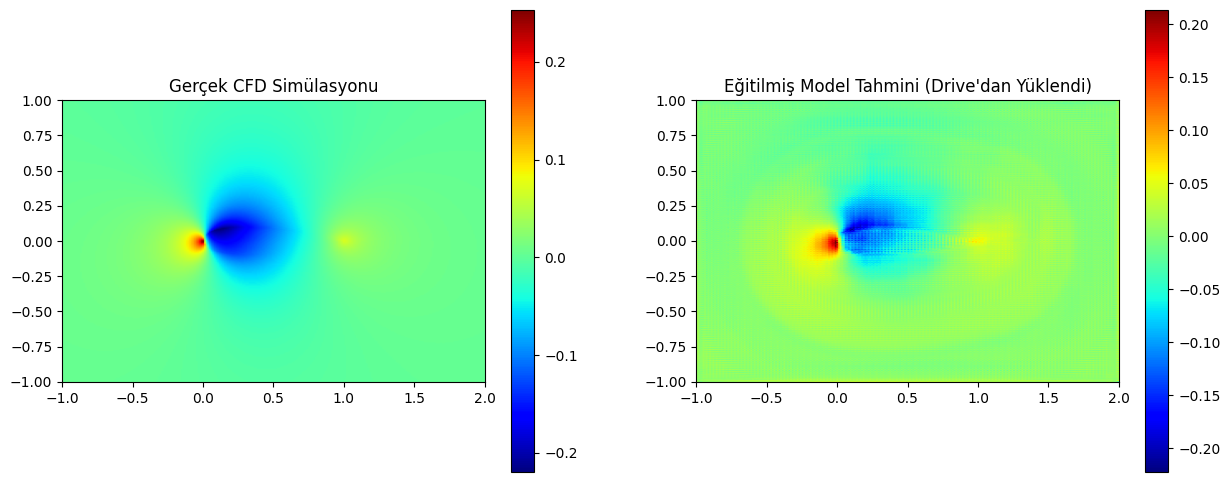

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from google.colab import drive

# 1. Drive'ı Bağla (Eğer bağlı değilse onay isteyecektir)
drive.mount('/content/drive')

# 2. Modelin İskeletini Tekrar Tanımlıyoruz (RAM sıfırlandığı için şart)
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class AeroResUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3): # in_channels=3 unutma!
        super(AeroResUNet, self).__init__()
        self.enc1 = ResBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = ResBlock(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ResBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ResBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ResBlock(128, 64)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final_conv(d1)

# 3. Veri Okuyucu Sınıfını Tekrar Tanımlıyoruz
class AeroTensorDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        data = torch.load(os.path.join(self.data_dir, self.files[idx]))
        return data['input'], data['target']

# 4. Modeli Yükleme ve Çıkarım (Inference) İşlemi
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Donanım: {device.type.upper()}")

# Boş iskeleti oluştur
model = AeroResUNet(in_channels=3, out_channels=3).to(device)

# Drive'daki eğitilmiş ağırlıkları içine doldur
model_path = '/content/drive/MyDrive/AeroML_Project/aero_resunet_v2_perfect.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval() # Eğitimi tamamen kapat (Çok kritik)

# 5. Test Verisini Getir ve Tahmin Yap
test_dir = '/content/drive/MyDrive/AeroML_Project/tensordata/test'
test_dataset = AeroTensorDataset(test_dir)

sample_idx = 0 # İstediğin test verisini buradan değiştirebilirsin
inputs, targets = test_dataset[sample_idx]

inputs = inputs.unsqueeze(0).to(device)

with torch.no_grad(): # Hafızayı yormadan sadece tahmin yap
    predictions = model(inputs)

# 6. Görselleştirme
pred_p = predictions.squeeze(0).cpu().numpy()[0]
target_p = targets.numpy()[0]

x_min, x_max, y_min, y_max = -1.0, 2.0, -1.0, 1.0

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

im1 = axs[0].imshow(target_p.T, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='jet')
axs[0].set_title("Gerçek CFD Simülasyonu")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(pred_p.T, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='jet')
axs[1].set_title("Eğitilmiş Model Tahmini (Drive'dan Yüklendi)")
fig.colorbar(im2, ax=axs[1])

plt.show()